#### Packages

In [1]:
## Common Packages
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,
                         summarize)
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


## Packages for this assignment
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score as f1
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from sklearn.metrics.pairwise import euclidean_distances
from ISLP.cluster import compute_linkage
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.exponential_smoothing.ets import ETSModel as ets 
from statsmodels.graphics.tsaplots import plot_acf 
from statsmodels.graphics.tsaplots import plot_pacf 
from statsmodels.tsa.arima.model import ARIMA 
from scipy.stats import kstest
from sklearn.preprocessing import PolynomialFeatures

from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns

import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import random
random.seed(0)

# Store Sales - Time Series Forecasting  

### Import Data

In [133]:
Sales = pd.read_csv('train.csv')
Sales

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [65]:
Sales = pd.read_csv('train.csv')
SalesTest = pd.read_csv('test.csv')

Sales = Sales[1500000:]
Sales

,id,date,store_nbr,family,sales,onpromotion
1500000,1500000,2015-04-24,46,HOME CARE,0.000,0
1500001,1500001,2015-04-24,46,LADIESWEAR,0.000,0
1500002,1500002,2015-04-24,46,LAWN AND GARDEN,3.000,0
1500003,1500003,2015-04-24,46,LINGERIE,7.000,0
1500004,1500004,2015-04-24,46,"LIQUOR,WINE,BEER",192.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [67]:
myTrain = Sales[:1300000]
myTest = Sales[1300001:]
myTrain

,id,date,store_nbr,family,sales,onpromotion
1500000,1500000,2015-04-24,46,HOME CARE,0.000,0
1500001,1500001,2015-04-24,46,LADIESWEAR,0.000,0
1500002,1500002,2015-04-24,46,LAWN AND GARDEN,3.000,0
1500003,1500003,2015-04-24,46,LINGERIE,7.000,0
1500004,1500004,2015-04-24,46,"LIQUOR,WINE,BEER",192.000,0
...,...,...,...,...,...,...
2799995,2799995,2017-04-25,22,FROZEN FOODS,80.102,3
2799996,2799996,2017-04-25,22,GROCERY I,2105.000,61
2799997,2799997,2017-04-25,22,GROCERY II,16.000,0
2799998,2799998,2017-04-25,22,HARDWARE,0.000,0


In [38]:
SalesTest[:3]

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2


### Select Store 1 Automotive & Reformat Date  
https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries-period-aliases

In [69]:
automotive = myTrain[myTrain['family'] == 'AUTOMOTIVE']
automotiveS1 = automotive[automotive['store_nbr'] == 1]
#automotiveS1["date"] = pd.to_datetime(automotiveS1['date'])
automotiveS1.index = automotiveS1["date"]
automotiveS1.index = pd.DatetimeIndex(automotiveS1.index).to_period('D')

#automotiveS1.index = automotiveS1['date']
automotiveS1 = automotiveS1['sales']
automotiveS1

date
2015-04-25    2.0
2015-04-26    0.0
2015-04-27    2.0
2015-04-28    6.0
2015-04-29    1.0
             ... 
2017-04-21    5.0
2017-04-22    5.0
2017-04-23    1.0
2017-04-24    6.0
2017-04-25    3.0
Freq: D, Name: sales, Length: 730, dtype: float64

In [70]:
automotive_myTest = myTest[myTest['family'] == 'AUTOMOTIVE']
automotiveS1_myTest = automotive_myTest[automotive_myTest['store_nbr'] == 1]
#automotiveS1["date"] = pd.to_datetime(automotiveS1['date'])
automotiveS1_myTest.index = automotiveS1_myTest["date"]
automotiveS1_myTest.index = pd.DatetimeIndex(automotiveS1_myTest.index).to_period('D')

#automotiveS1.index = automotiveS1['date']
automotiveS1_myTest = automotiveS1_myTest['sales']
automotiveS1_myTest

date
2017-04-26    2.0
2017-04-27    8.0
2017-04-28    3.0
2017-04-29    2.0
2017-04-30    3.0
             ... 
2017-08-11    1.0
2017-08-12    6.0
2017-08-13    1.0
2017-08-14    1.0
2017-08-15    4.0
Freq: D, Name: sales, Length: 112, dtype: float64

In [77]:
min_date_myTest = automotiveS1_myTest.index.min()
max_date_myTest = automotiveS1_myTest.index.max()
print('myTest Minimum date:', min_date_myTest)
print('myTest Maximum date:', max_date_myTest)

myTest Minimum date: 2017-04-26
myTest Maximum date: 2017-08-15


In [128]:
automotiveTest = SalesTest[SalesTest['family'] == 'AUTOMOTIVE']
automotiveS1Test = automotiveTest[automotiveTest['store_nbr'] == 1]

automotiveS1Test.index = automotiveS1Test['date']
#automotiveS1Test = automotiveS1Test['id']

automotiveS1Test

,id,date,store_nbr,family,onpromotion
date,,,,,
2017-08-16,3000888,2017-08-16,1,AUTOMOTIVE,0
2017-08-17,3002670,2017-08-17,1,AUTOMOTIVE,0
2017-08-18,3004452,2017-08-18,1,AUTOMOTIVE,0
2017-08-19,3006234,2017-08-19,1,AUTOMOTIVE,0
2017-08-20,3008016,2017-08-20,1,AUTOMOTIVE,0
2017-08-21,3009798,2017-08-21,1,AUTOMOTIVE,0
2017-08-22,3011580,2017-08-22,1,AUTOMOTIVE,0
2017-08-23,3013362,2017-08-23,1,AUTOMOTIVE,0
2017-08-24,3015144,2017-08-24,1,AUTOMOTIVE,0


https://saturncloud.io/blog/getting-min-and-max-dates-from-a-pandas-dataframe/#:~:text=Method%201%3A%20Using%20min()%20and%20max()&text=We%20want%20to%20find%20the,()%20functions%20provided%20by%20pandas.&text=In%20the%20above%20code%2C%20we,datetime%20format%20using%20the%20pd.

In [74]:
min_date = automotiveS1Test.index.min()
max_date = automotiveS1Test.index.max()
print('Minimum date:', min_date)
print('Maximum date:', max_date)

Minimum date: 2017-08-16
Maximum date: 2017-08-31


## ETS Model

<Axes: xlabel='date'>

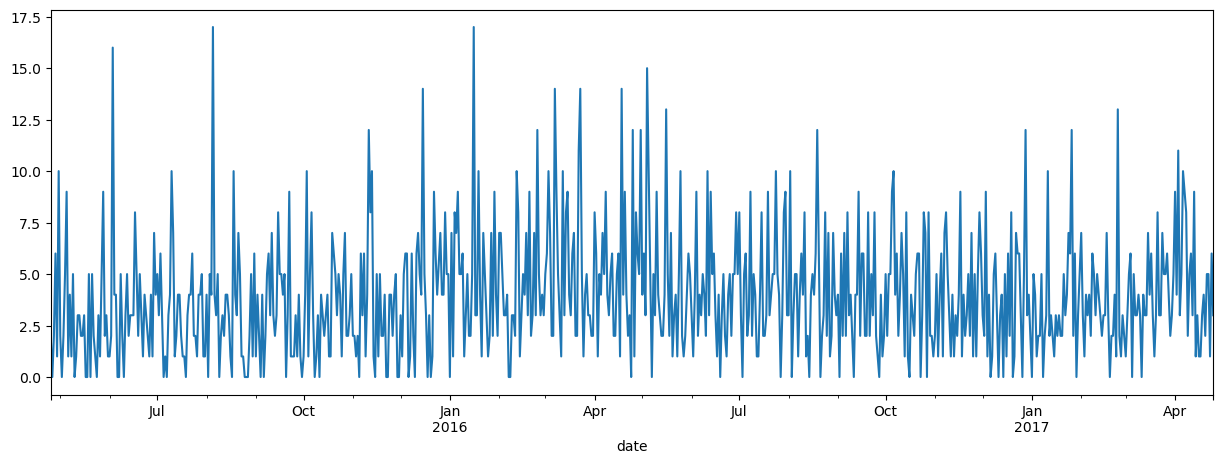

In [75]:
plt.figure(figsize=(15, 5))
trend = pd.Series(automotiveS1) 
trend.plot() 

https://www.statsmodels.org/stable/generated/statsmodels.tsa.exponential_smoothing.ets.ETSModel.html

#### ETS with 365 day season

In [86]:
modelETS = ets(automotiveS1, error="add", trend="add", seasonal="add", damped_trend=True, seasonal_periods=365,) 
fitETS = modelETS.fit() 


MSE:  6.137877843193165
RMSE:  2.4774740852717643
MAE:  1.806268600085358
MAPE:  inf
ME:  -0.12948546438676892
MPE:  nan
MSE:  9.674945840182351
RMSE:  3.1104574969258705
MAE:  2.324621718739219
MAPE:  inf
ME:  -0.597377424897074
MPE:  inf


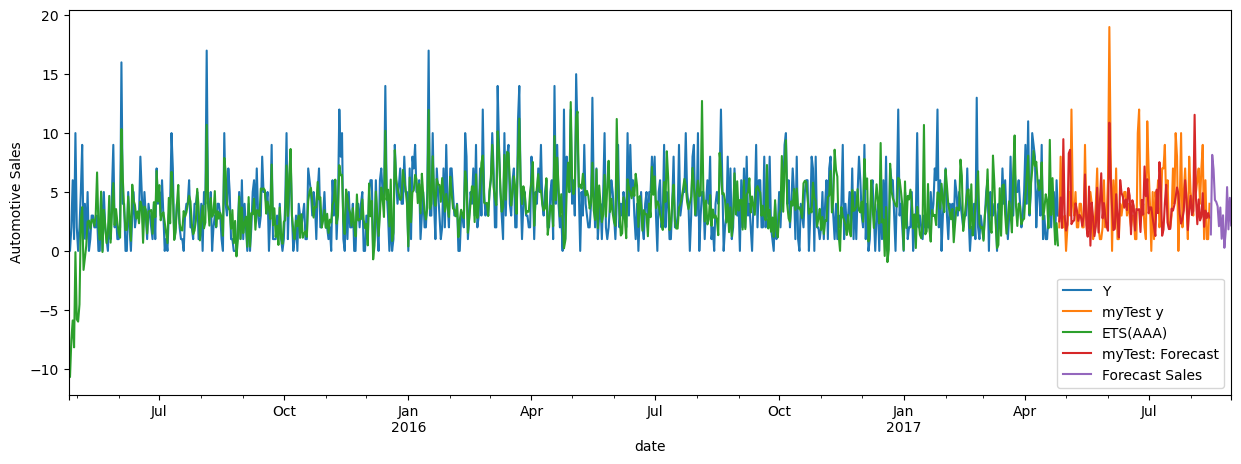

In [112]:
predETS_myTest = fitETS.get_prediction(start=min_date_myTest, end=max_date_myTest) 
predETS = fitETS.get_prediction(start=min_date, end=max_date) 

df = predETS.summary_frame(alpha=0.05) 
df_myTest = predETS_myTest.summary_frame(alpha=0.05) 
df_myTest['test'] = automotiveS1_myTest 

plt.figure(figsize=(15, 5))
automotiveS1.plot(label="Y") 
plt.ylabel("Automotive Sales")
df_myTest['test'].plot(label='myTest y') 
fitETS.fittedvalues.plot(label="ETS(AAA)") 
df_myTest['mean'].plot(label='myTest: Forecast')
df['mean'].plot(label='Forecast Sales') 
plt.legend() 
error = fitETS.fittedvalues - automotiveS1
print("MSE: ", np.mean(error**2))
print("RMSE: ", np.sqrt(np.mean(error**2)))
print("MAE: ", np.mean(abs(error)))
print("MAPE: ", np.mean(abs(error)/automotiveS1))
print("ME: ", np.mean(error))
print("MPE: ", np.mean(error/automotiveS1))

TestError = df_myTest['mean'] - automotiveS1_myTest
print("MSE: ", np.mean(TestError**2))
print("RMSE: ", np.sqrt(np.mean(TestError**2)))
print("MAE: ", np.mean(abs(TestError)))
print("MAPE: ", np.mean(abs(TestError)/automotiveS1_myTest))
print("ME: ", np.mean(TestError))
print("MPE: ", np.mean(TestError/automotiveS1_myTest))

In [130]:



automotiveS1Test['sales'] = df['mean']
output = automotiveS1Test[['id', 'sales']]
print(output)
output.to_csv('model_ETS365_AutomotiveStore1.csv', index = True)

                 id     sales
date                         
2017-08-16  3000888  1.401230
2017-08-17  3002670  8.150349
2017-08-18  3004452  6.917728
2017-08-19  3006234  4.328293
2017-08-20  3008016  4.159080
2017-08-21  3009798  3.791574
2017-08-22  3011580  2.094354
2017-08-23  3013362  3.681038
2017-08-24  3015144  1.030962
2017-08-25  3016926  3.023761
2017-08-26  3018708  0.265597
2017-08-27  3020490  1.694998
2017-08-28  3022272  5.416328
2017-08-29  3024054  1.829503
2017-08-30  3025836  4.506945
2017-08-31  3027618  2.166259


#### ETS with 30 day season

MSE:  8.197754754985054
RMSE:  2.863172149030696
MAE:  2.205660106624551
MAPE:  inf
ME:  -0.06679208057133702
MPE:  inf
MSE:  9.549043448163621
RMSE:  3.0901526577442127
MAE:  2.2971457400006843
MAPE:  inf
ME:  -0.17493515262162201
MPE:  inf


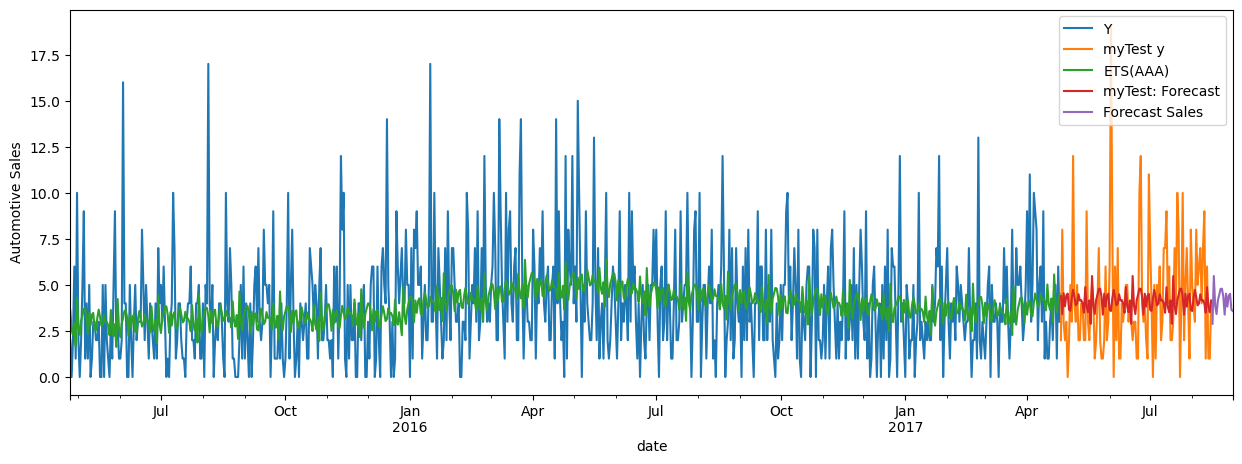

In [104]:
modelETS2 = ets(automotiveS1, error="add", trend="add", seasonal="add", damped_trend=True, seasonal_periods=30,) 
fitETS2 = modelETS2.fit() 

predETS_myTest = fitETS2.get_prediction(start=min_date_myTest, end=max_date_myTest) 
predETS = fitETS2.get_prediction(start=min_date, end=max_date) 

df = predETS.summary_frame(alpha=0.05) 
df_myTest = predETS_myTest.summary_frame(alpha=0.05) 
df_myTest['test'] = automotiveS1_myTest 

plt.figure(figsize=(15, 5))
automotiveS1.plot(label="Y") 
plt.ylabel("Automotive Sales")
df_myTest['test'].plot(label='myTest y') 
fitETS2.fittedvalues.plot(label="ETS(AAA)") 
df_myTest['mean'].plot(label='myTest: Forecast')
df['mean'].plot(label='Forecast Sales') 
plt.legend() 
error = fitETS2.fittedvalues - automotiveS1
print("MSE: ", np.mean(error**2))
print("RMSE: ", np.sqrt(np.mean(error**2)))
print("MAE: ", np.mean(abs(error)))
print("MAPE: ", np.mean(abs(error)/automotiveS1))
print("ME: ", np.mean(error))
print("MPE: ", np.mean(error/automotiveS1))
TestError = df_myTest['mean'] - automotiveS1_myTest
print("MSE: ", np.mean(TestError**2))
print("RMSE: ", np.sqrt(np.mean(TestError**2)))
print("MAE: ", np.mean(abs(TestError)))
print("MAPE: ", np.mean(abs(TestError)/automotiveS1_myTest))
print("ME: ", np.mean(TestError))
print("MPE: ", np.mean(TestError/automotiveS1_myTest))

#### ETS with 7 day season

MSE:  8.071213658784957
RMSE:  2.8409881483006854
MAE:  2.1497663774204887
MAPE:  inf
ME:  -0.06499146739152382
MPE:  inf
MSE:  10.468399236901769
RMSE:  3.2354905712892705
MAE:  2.4330194096750843
MAPE:  inf
ME:  0.006866382829724039
MPE:  inf


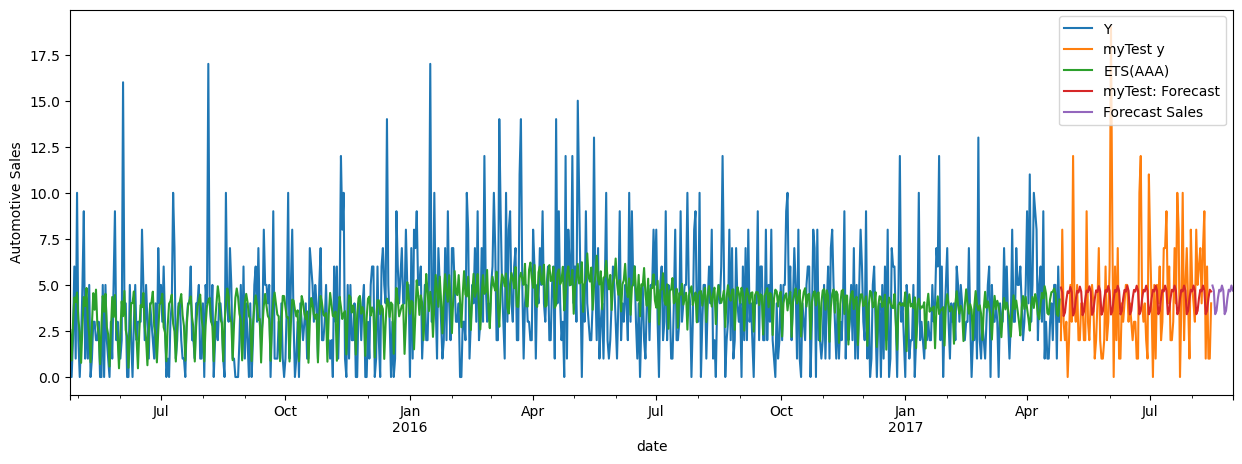

In [105]:
modelETS3 = ets(automotiveS1, error="add", trend="add", seasonal="add", damped_trend=True, seasonal_periods=7,) 
fitETS3 = modelETS3.fit() 
predETS_myTest = fitETS3.get_prediction(start=min_date_myTest, end=max_date_myTest) 
predETS = fitETS3.get_prediction(start=min_date, end=max_date) 

df = predETS.summary_frame(alpha=0.05) 
df_myTest = predETS_myTest.summary_frame(alpha=0.05) 
df_myTest['test'] = automotiveS1_myTest 

plt.figure(figsize=(15, 5))
automotiveS1.plot(label="Y") 
plt.ylabel("Automotive Sales")
df_myTest['test'].plot(label='myTest y') 
fitETS3.fittedvalues.plot(label="ETS(AAA)") 
df_myTest['mean'].plot(label='myTest: Forecast')
df['mean'].plot(label='Forecast Sales') 
plt.legend() 
error = fitETS3.fittedvalues - automotiveS1
print("MSE: ", np.mean(error**2))
print("RMSE: ", np.sqrt(np.mean(error**2)))
print("MAE: ", np.mean(abs(error)))
print("MAPE: ", np.mean(abs(error)/automotiveS1))
print("ME: ", np.mean(error))
print("MPE: ", np.mean(error/automotiveS1))
TestError = df_myTest['mean'] - automotiveS1_myTest
print("MSE: ", np.mean(TestError**2))
print("RMSE: ", np.sqrt(np.mean(TestError**2)))
print("MAE: ", np.mean(abs(TestError)))
print("MAPE: ", np.mean(abs(TestError)/automotiveS1_myTest))
print("ME: ", np.mean(TestError))
print("MPE: ", np.mean(TestError/automotiveS1_myTest))

## ARIMA Model  

### ARIMA applied to Automotive at Store 1

In [88]:
from statsmodels.tsa.arima.model import ARIMA 

modelARIMA1 = ARIMA(automotiveS1) 
fitARIMA1 = modelARIMA1.fit() 

MSE:  8.601508725864914
RMSE:  2.9328328840670266
MAE:  2.2481064903867565
MAPE:  inf
ME:  -5.0169175449082416e-06
MPE:  inf
MSE:  9.4708041500918
RMSE:  3.0774671647463276
MAE:  2.2377695281739003
MAPE:  inf
ME:  -0.3665901441191105
MPE:  inf


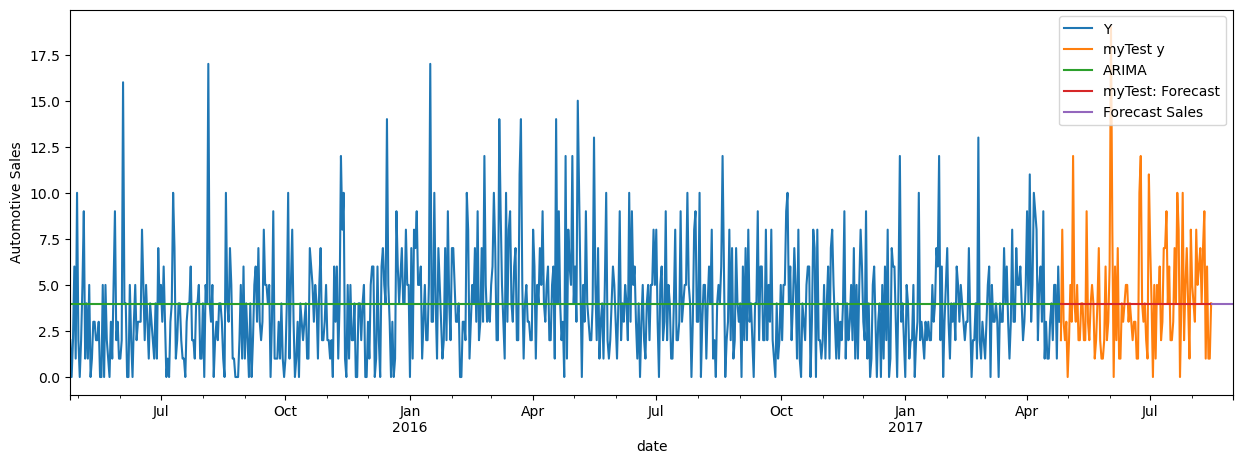

In [106]:
predARIMA_myTest = fitARIMA1.get_prediction(start=min_date_myTest, end=max_date_myTest) 
predARIMA = fitARIMA1.get_prediction(start=min_date, end=max_date) 

df = predARIMA.summary_frame(alpha=0.05) 
df_myTest = predARIMA_myTest.summary_frame(alpha=0.05) 
df_myTest['test'] = automotiveS1_myTest 

plt.figure(figsize=(15, 5))
automotiveS1.plot(label="Y") 
plt.ylabel("Automotive Sales")
df_myTest['test'].plot(label='myTest y') 
fitARIMA1.fittedvalues.plot(label="ARIMA") 
df_myTest['mean'].plot(label='myTest: Forecast')
df['mean'].plot(label='Forecast Sales') 
plt.legend() 
error = fitARIMA1.fittedvalues - automotiveS1
print("MSE: ", np.mean(error**2))
print("RMSE: ", np.sqrt(np.mean(error**2)))
print("MAE: ", np.mean(abs(error)))
print("MAPE: ", np.mean(abs(error)/automotiveS1))
print("ME: ", np.mean(error))
print("MPE: ", np.mean(error/automotiveS1))
TestError = df_myTest['mean'] - automotiveS1_myTest
print("MSE: ", np.mean(TestError**2))
print("RMSE: ", np.sqrt(np.mean(TestError**2)))
print("MAE: ", np.mean(abs(TestError)))
print("MAPE: ", np.mean(abs(TestError)/automotiveS1_myTest))
print("ME: ", np.mean(TestError))
print("MPE: ", np.mean(TestError/automotiveS1_myTest))

### ARIMA(1, 1, 1) applied to Automotive at Store 1

In [93]:
from statsmodels.tsa.arima.model import ARIMA 

modelARIMA2 = ARIMA(automotiveS1, order=(1, 1, 1)) 
fitARIMA2 = modelARIMA2.fit() 

MSE:  8.4813321562786
RMSE:  2.912272678901926
MAE:  2.2431689852786363
MAPE:  inf
ME:  -0.08543706357898165
MPE:  inf
MSE:  9.393813553995775
RMSE:  3.0649328791991146
MAE:  2.2492838560803974
MAPE:  inf
ME:  -0.23957834015402607
MPE:  inf


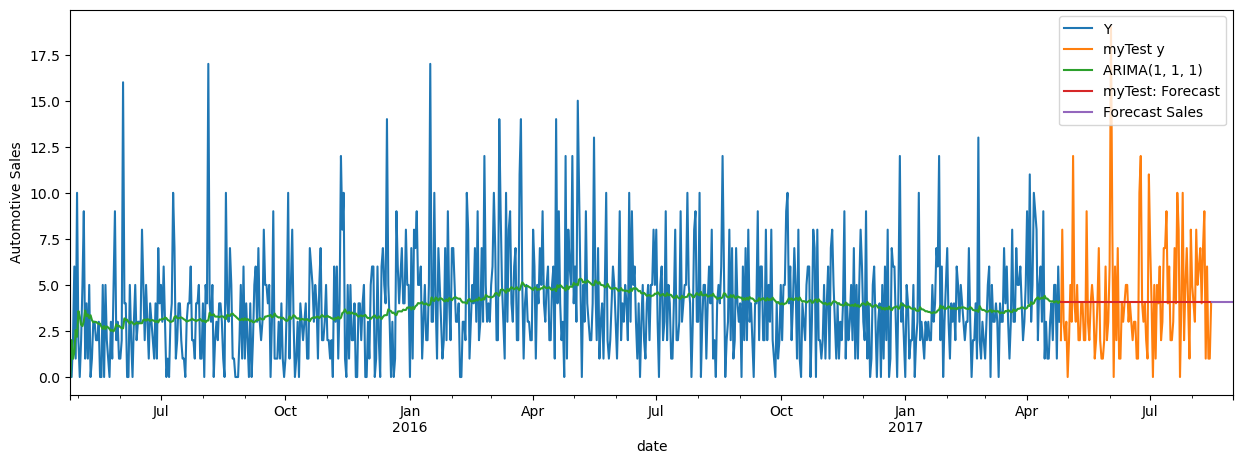

In [131]:
predARIMA_myTest = fitARIMA2.get_prediction(start=min_date_myTest, end=max_date_myTest) 
predARIMA = fitARIMA2.get_prediction(start=min_date, end=max_date) 

df = predARIMA.summary_frame(alpha=0.05) 
df_myTest = predARIMA_myTest.summary_frame(alpha=0.05) 
df_myTest['test'] = automotiveS1_myTest 

plt.figure(figsize=(15, 5))
automotiveS1.plot(label="Y") 
plt.ylabel("Automotive Sales")
df_myTest['test'].plot(label='myTest y') 
fitARIMA2.fittedvalues.plot(label="ARIMA(1, 1, 1)") 
df_myTest['mean'].plot(label='myTest: Forecast')
df['mean'].plot(label='Forecast Sales') 
plt.legend() 
error = fitARIMA2.fittedvalues - automotiveS1
print("MSE: ", np.mean(error**2))
print("RMSE: ", np.sqrt(np.mean(error**2)))
print("MAE: ", np.mean(abs(error)))
print("MAPE: ", np.mean(abs(error)/automotiveS1))
print("ME: ", np.mean(error))
print("MPE: ", np.mean(error/automotiveS1))
TestError = df_myTest['mean'] - automotiveS1_myTest
print("MSE: ", np.mean(TestError**2))
print("RMSE: ", np.sqrt(np.mean(TestError**2)))
print("MAE: ", np.mean(abs(TestError)))
print("MAPE: ", np.mean(abs(TestError)/automotiveS1_myTest))
print("ME: ", np.mean(TestError))
print("MPE: ", np.mean(TestError/automotiveS1_myTest))

In [132]:
automotiveS1Test['sales'] = df['mean']
output = automotiveS1Test[['id', 'sales']]
print(output)
output.to_csv('model_ARIMA(1,1,1)_AutomotiveStore1.csv', index = True)

                 id     sales
date                         
2017-08-16  3000888  4.063993
2017-08-17  3002670  4.063993
2017-08-18  3004452  4.063993
2017-08-19  3006234  4.063993
2017-08-20  3008016  4.063993
2017-08-21  3009798  4.063993
2017-08-22  3011580  4.063993
2017-08-23  3013362  4.063993
2017-08-24  3015144  4.063993
2017-08-25  3016926  4.063993
2017-08-26  3018708  4.063993
2017-08-27  3020490  4.063993
2017-08-28  3022272  4.063993
2017-08-29  3024054  4.063993
2017-08-30  3025836  4.063993
2017-08-31  3027618  4.063993


### Stepwise ARIMA applied to Automotive at Store 1

This code is adapted from: 

https://www.geeksforgeeks.org/python-arima-model-for-time-series-forecasting/

In [111]:
from pmdarima import auto_arima 
  
# Ignore harmless warnings 
import warnings 
warnings.filterwarnings("ignore") 
  
# Fit auto_arima function to AirPassengers dataset 
stepwise_fit = auto_arima(automotiveS1, start_p = 1, start_q = 1, 
                          max_p = 3, max_q = 3, m = 12, 
                          start_P = 0, seasonal = True, 
                          d = None, D = 1, trace = True, 
                          error_action ='ignore',   # we don't want to know if an order does not work 
                          suppress_warnings = True,  # we don't want convergence warnings 
                          stepwise = True)           # set to stepwise 
  
# To print the summary 
stepwise_fit.summary() 

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.40 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=4106.529, Time=0.06 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=3843.217, Time=0.59 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.72 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=4104.531, Time=0.05 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=4108.523, Time=0.17 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=3771.826, Time=1.04 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=2.00 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=3769.887, Time=1.00 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=3841.941, Time=0.37 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.34 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=3771.823, Time=0.94 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=3773.7

<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                 
================================================================================
Dep. Variable:                        y   No. Observations:                  730
Model:             SARIMAX(2, 1, 0, 12)   Log Likelihood               -1881.050
Date:                  Sat, 22 Feb 2025   AIC                           3768.100
Time:                          19:03:03   BIC                           3781.830
Sample:                      04-25-2015   HQIC                          3773.401
                           - 04-25-2017                                         
Covariance Type:                    opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.7416      0.033    -22.533      0.000      -0.806      -0.677
ar.S.L24      -0.3166      0.032     -9.947      0.000      -0.379      -0.254
sigma2        10.9343      0.462     23.687      0.000      10.030      11.839
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                83.77
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               0.92   Skew:                             0.62
Prob(H) (two-sided):                  0.52   Kurtosis:                         4.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### ARIMA(0,0,0)(2,1,0)[12]

In [95]:
from statsmodels.tsa.arima.model import ARIMA 

modelARIMA3 = ARIMA(automotiveS1, order=(0, 0, 0), seasonal_order=(2, 1, 0, 12)) 
fitARIMA3 = modelARIMA3.fit() 

MSE:  11.22571555734021
RMSE:  3.350479899557705
MAE:  2.5909884576966524
MAPE:  inf
ME:  -0.09608258374328912
MPE:  nan
MSE:  11.5750746980107
RMSE:  3.4022161451046435
MAE:  2.745582703783542
MAPE:  inf
ME:  0.16697134276929354
MPE:  inf


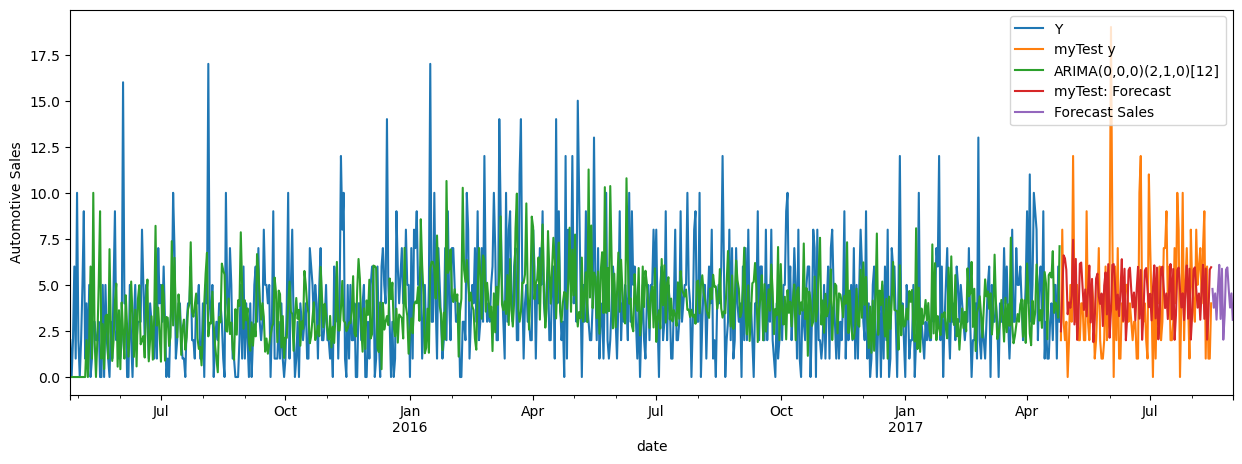

In [109]:
predARIMA_myTest = fitARIMA3.get_prediction(start=min_date_myTest, end=max_date_myTest) 
predARIMA = fitARIMA3.get_prediction(start=min_date, end=max_date) 

df = predARIMA.summary_frame(alpha=0.05) 
df_myTest = predARIMA_myTest.summary_frame(alpha=0.05) 
df_myTest['test'] = automotiveS1_myTest 

plt.figure(figsize=(15, 5))
automotiveS1.plot(label="Y") 
plt.ylabel("Automotive Sales")
df_myTest['test'].plot(label='myTest y') 
fitARIMA3.fittedvalues.plot(label="ARIMA(0,0,0)(2,1,0)[12]") 
df_myTest['mean'].plot(label='myTest: Forecast')
df['mean'].plot(label='Forecast Sales') 
plt.legend() 
error = fitARIMA3.fittedvalues - automotiveS1
print("MSE: ", np.mean(error**2))
print("RMSE: ", np.sqrt(np.mean(error**2)))
print("MAE: ", np.mean(abs(error)))
print("MAPE: ", np.mean(abs(error)/automotiveS1))
print("ME: ", np.mean(error))
print("MPE: ", np.mean(error/automotiveS1))
TestError = df_myTest['mean'] - automotiveS1_myTest
print("MSE: ", np.mean(TestError**2))
print("RMSE: ", np.sqrt(np.mean(TestError**2)))
print("MAE: ", np.mean(abs(TestError)))
print("MAPE: ", np.mean(abs(TestError)/automotiveS1_myTest))
print("ME: ", np.mean(TestError))
print("MPE: ", np.mean(TestError/automotiveS1_myTest))

### ARIMA with All Predictor  
https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html

#### Data Prep

In [10]:
Sales.index = Sales["date"]
Sales.index = pd.DatetimeIndex(Sales.index).to_period('D')
Sales = Sales.drop(columns=['id', 'date'])
#data = Sales.to_numpy()
y = Sales['sales']
Xs = Sales.drop(columns=['sales'])


In [11]:
Xs

,store_nbr,family,onpromotion
date,,,
2015-06-19,51,POULTRY,32
2015-06-19,51,PREPARED FOODS,1
2015-06-19,51,PRODUCE,1
2015-06-19,51,SCHOOL AND OFFICE SUPPLIES,0
2015-06-19,51,SEAFOOD,6
...,...,...,...
2017-08-15,9,POULTRY,0
2017-08-15,9,PREPARED FOODS,1
2017-08-15,9,PRODUCE,148


In [12]:
Xnew = pd.get_dummies(Xs, columns=['family'], drop_first = False)
Xnew

,store_nbr,onpromotion,family_AUTOMOTIVE,family_BABY CARE,family_BEAUTY,family_BEVERAGES,family_BOOKS,family_BREAD/BAKERY,family_CELEBRATION,family_CLEANING,...,family_MAGAZINES,family_MEATS,family_PERSONAL CARE,family_PET SUPPLIES,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,
2015-06-19,51,32,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2015-06-19,51,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2015-06-19,51,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2015-06-19,51,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2015-06-19,51,6,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-15,9,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2017-08-15,9,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2017-08-15,9,148,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [13]:
data = Xnew.to_numpy()

#### ARIMA Model

In [30]:
from statsmodels.tsa.arima.model import ARIMA 

model = ARIMA(y.astype(float), exog = data.astype(float)) 
fit = model.fit() 

pred = fit.get_prediction(start=min_date, end=max_date) 
df3 = pred.summary_frame() 


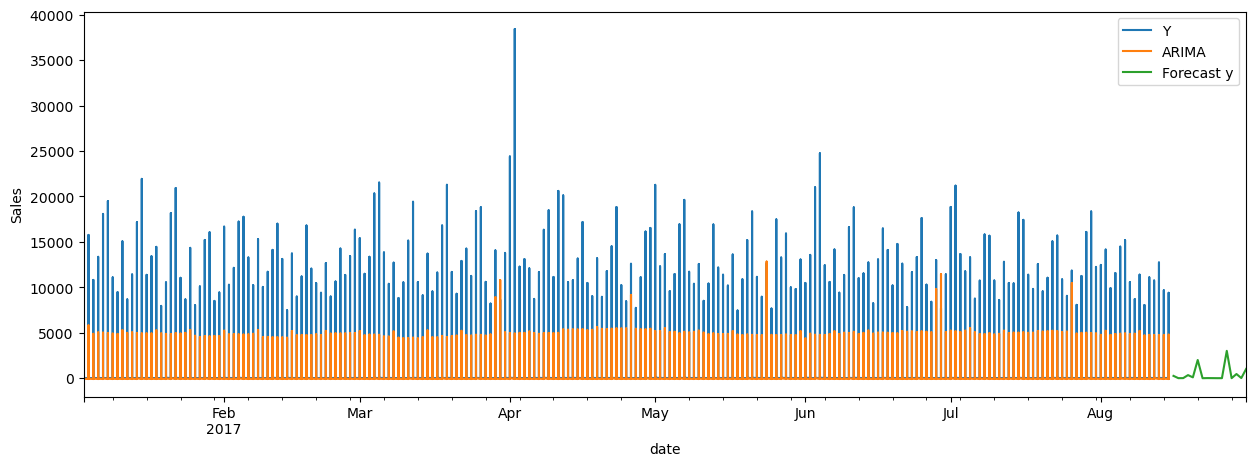

In [31]:
plt.figure(figsize=(15, 5))

y[1000000:].plot(label="Y") 
plt.ylabel("Sales") 
fit.fittedvalues[1000000:].plot(label="ARIMA") 
df3['mean'].plot(label='Forecast y') 
plt.legend() 

In [32]:
error = fit.fittedvalues - y
print("MSE: ", np.mean(error**2))

MSE:  691811.1832898523


### ARIMA(1, 1, 1) with All Predictor  


In [14]:
from statsmodels.tsa.arima.model import ARIMA 

model = ARIMA(y.astype(float), exog = data.astype(float),  order=(1,1,1),) 
fit = model.fit() 

pred = fit.get_prediction(start=min_date, end=max_date) 
df3 = pred.summary_frame() 


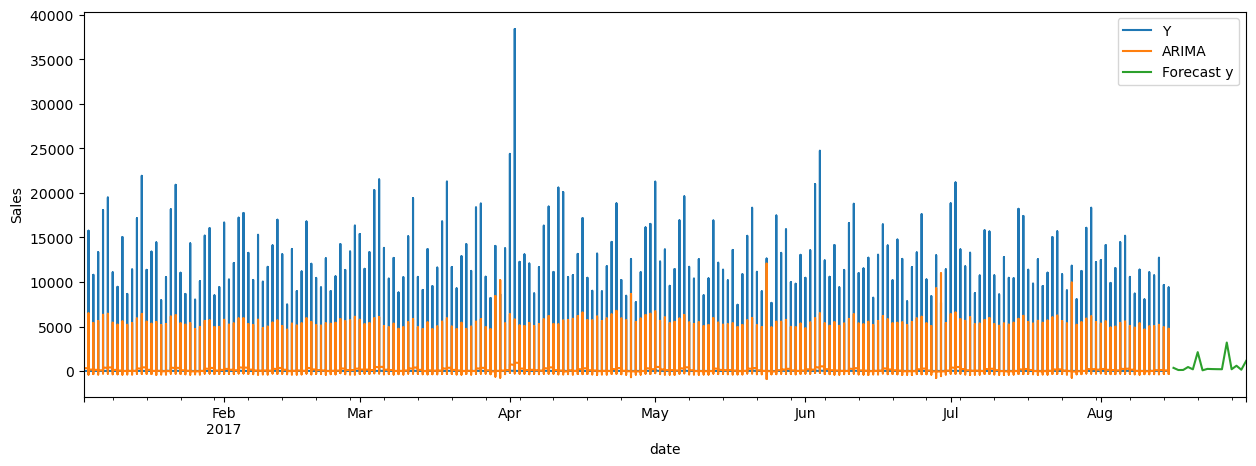

In [17]:
plt.figure(figsize=(15, 5))

y[1000000:].plot(label="Y") 
plt.ylabel("Sales") 
fit.fittedvalues[1000000:].plot(label="ARIMA") 
df3['mean'].plot(label='Forecast y') 
plt.legend() 

In [29]:
error = fit.fittedvalues - y
print("MSE: ", np.mean(error**2))

MSE:  645246.7219142064
